In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

import xarray as xr
import geopandas as gpd
from scipy.spatial import cKDTree

# Weather station observations

The downloaded version comes at a monthly resolution for 32 stations in Casanare, Colombia.

In [92]:
# "Shapefile" with coordinates of weather stations
gdf = gpd.read_parquet('data/location_stations.parquet')

In [104]:
gdf_slice = gdf[gdf['dDepartment']=='Casanare'].copy()

In [ ]:
# Dataset with monthly measurements of accumulated precipitation
df_prcp = pd.read_parquet('data/station_observations.parquet')

In [ ]:
# Watch first 3 rows of data
df_prcp.head(3)

,stationId,stationName,variable,parameter,date,units,value,approvalLevel
0,35215020,AEROPUERTO YOPAL - AUT [35215020],PRECIPITACION,Precipitación total mensual,2006-01-01,mm,31.0,Preliminar
1,35215020,AEROPUERTO YOPAL - AUT [35215020],PRECIPITACION,Precipitación total mensual,2006-02-01,mm,0.0,Preliminar
2,35215020,AEROPUERTO YOPAL - AUT [35215020],PRECIPITACION,Precipitación total mensual,2006-03-01,mm,222.2,Preliminar


In [51]:
# Merge historical records with coordinates by stationId
df_prcp = gdf[['stationId', 'latitude', 'longitude', 'altitude']].merge(
    df_prcp,
    how = 'right',
    on = 'stationId'
)

In [52]:
df_prcp.head(3)

,stationId,latitude,longitude,altitude,stationName,variable,parameter,date,units,value,approvalLevel
0,35215020,5.320444,-72.3875,325.0,AEROPUERTO YOPAL - AUT [35215020],PRECIPITACION,Precipitación total mensual,2006-01-01,mm,31.0,Preliminar
1,35215020,5.320444,-72.3875,325.0,AEROPUERTO YOPAL - AUT [35215020],PRECIPITACION,Precipitación total mensual,2006-02-01,mm,0.0,Preliminar
2,35215020,5.320444,-72.3875,325.0,AEROPUERTO YOPAL - AUT [35215020],PRECIPITACION,Precipitación total mensual,2006-03-01,mm,222.2,Preliminar


# Read precipitation data from CHIRPS

In [78]:
gdf_co = gpd.read_parquet('data/colombia_polygons.parquet')

In [ ]:
# Reading gridded dat from CHIRPS for daily precipitation
# The data is located at Suyana's S3 bucket and requires a direct connection to S3 to avoid putting credentials
ds_chirps = xr.open_mfdataset('s3://suyana-pricing/colombia/valles/sources/UCSB_prcp_*.zarr', engine='zarr')

In [ ]:
# Load pre-processed CHIRPS estimates from local file (alternative to S3 block above)
df_reduced_chirps = pd.read_parquet('data/chirps_estimates_reduced.parquet')
df_pixels = pd.read_parquet('data/chirps_metadata_reduced.parquet')
df_reduced_chirps.head(3)

In [57]:
# Qucik look of how the data is structured
ds_chirps

<xarray.Dataset> Size: 549MB
Dimensions:      (time: 10958, lat: 97, lon: 129)
Coordinates:
    band         int64 8B 1
  * lat          (lat) float64 776B 6.425 6.375 6.325 ... 1.725 1.675 1.625
  * lon          (lon) float64 1kB -76.22 -76.17 -76.12 ... -69.92 -69.87 -69.82
  * time         (time) datetime64[ns] 88kB 1996-01-01 1996-01-02 ... 2025-12-31
Data variables:
    prcp         (time, lat, lon) float32 548MB dask.array<chunksize=(92, 25, 65), meta=np.ndarray>
    spatial_ref  (time) int64 88kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0

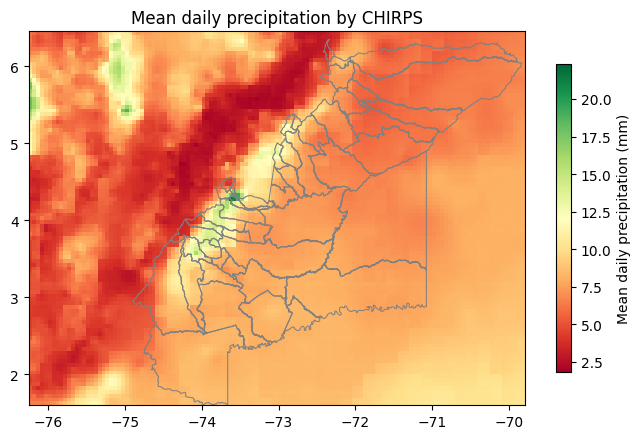

In [83]:
# Quick plot of mean daily precipitation
cmap = cm.RdYlGn
ds_mean = ds_chirps.mean(dim='time') # This collapses the time dimension and produces the mean of each longitude-latitude pair

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
gdf_co.boundary.plot(ax=ax, color='gray', linewidth=0.75)
mesh = ax.pcolormesh(ds_mean['lon'], ds_mean['lat'], ds_mean['prcp'], cmap=cmap)

ax.set_title('Mean daily precipitation by CHIRPS')

fig.colorbar(mesh, ax=ax, label='Mean daily precipitation (mm)', shrink=0.5)

# Selecting nearest pixel to weather stations

In [85]:
def get_coordinates(ds: xr.Dataset):
    """Get lon, lat and time coordinates from dataset"""

    lon_coord = {'lon', 'Lon', 'longitude', 'Longitude', 'x', 'X'}.intersection(set(ds.dims))
    lat_coord = {'lat', 'Lat', 'latitude', 'Latitude', 'y', 'Y'}.intersection(set(ds.dims))
    time_coord = {'time', 'valid_time', 'Time', 'date', 'Date'}.intersection(set(ds.dims))

    if len(lon_coord)>0:
        lon_var = lon_coord.pop()
    else:
        lon_var = None
        #raise NameError('No longitude coordinate found')
    if len(lat_coord)>0:
        lat_var = lat_coord.pop()
    else:
        lat_var = None
        #raise NameError('No latitude coordinate found')
    if len(time_coord)>0:
        time_var = time_coord.pop()
    else:
        time_var = None
    
    return lon_var, lat_var, time_var

In [86]:
def match_grid_points(ds_sample, df_target, sample_coords = ('lon', 'lat'), target_coords = ('lon', 'lat'), k=1):
    '''Compute the nearest neighbour from grid to coordinates in dataframe'''
    # Getting names for actual coordinates
    lon_target, lat_target = target_coords
    lon_sample, lat_sample = sample_coords
   
    # Target coordinates
    df_t = df_target.drop_duplicates(subset=[lon_target, lat_target]).copy()
    df_t = df_t.reset_index(drop=True).reset_index()
    df_target = df_target.merge(
        df_t[['index', lon_target, lat_target]],
        how='left',
        on=[lon_target, lat_target]
    )
    if sample_coords == target_coords:
        df_t = df_t.rename(columns={
            lon_target: f'{lon_target}_target',
            lat_target: f'{lat_target}_target',
        })
        lon_target, lat_target = f'{lon_target}_target', f'{lat_target}_target'

    # Sample coordinates
    if isinstance(ds_sample, pd.DataFrame):
        df_s = ds_sample[[lon_sample, lat_sample]].drop_duplicates().reset_index(drop=True)
    elif isinstance(ds_sample, xr.Dataset):
        df_s = ds_sample[[lon_sample, lat_sample]].to_dataframe().reset_index()

    # Nearest Neighbor Algorithm
    tree = cKDTree(df_s)
    dist, idx = tree.query(df_t[[lon_target, lat_target]], k=k)

    # Join Sample coordinate to target coordinates
    df_join = df_s.iloc[idx.flatten()].copy()
    df_join['index'] = np.repeat(df_t.index, k)
    df_join["distance"] = dist.flatten()
    df_target = df_target.merge(
        df_join,
        how = 'left',
        on = 'index',
        suffixes = ('_target', '')
    )
    df_target = df_target.drop(columns='index')

    return df_target

In [87]:
def select_coordinates(ds, gdf_target, grid_coords = ('lon', 'lat')):
    """Select in-situ coordinate points from grid, ds and gdf must share the same grid coord names"""
    lon_grid, lat_grid = grid_coords
    ds_stacked = ds.stack(points = (lat_grid, lon_grid))

    # Get coordinates from weather stations
    df_coords_station = gdf_target[[lat_grid, lon_grid]].drop_duplicates().reset_index(drop=True)
    target_index = pd.MultiIndex.from_frame(df_coords_station)
    
    #Subset the Master Table with locations of interest
    ds_subset = ds_stacked.sel(points=target_index)
    return ds_subset

In [88]:
def create_cluster_coord(ds_orig, gdf_orig, cluster_var, method='within', check_var=None, k=6):
    ds = ds_orig.copy()
    gdf = gdf_orig.copy()

    # Extract lon and lat from the dataset
    lon_var, lat_var, time_var = get_coordinates(ds)
    points = ds[[lat_var, lon_var]].to_dataframe().reset_index()  

    # Create a DataFrame of points
    points = gpd.GeoDataFrame(
        points,
        geometry=gpd.points_from_xy(points[lon_var], points[lat_var]),
        crs=gdf.crs
    )

    # Perform spatial join
    if method == 'within':
        points = gpd.sjoin(points, gdf[[cluster_var, "geometry"]], how="left", predicate="within")
        # Assign as coordinate to the dataset
        ds_points = points.set_index([lat_var, lon_var])[[cluster_var]]
        ds_points = ds_points.to_xarray().set_coords(cluster_var)
        ds = xr.merge([ds, ds_points])
        # Create a pixel assignation dataframe
        df_cluster = ds[[lon_var, lat_var, cluster_var]].to_dataframe()
        df_cluster = df_cluster.reset_index().dropna(subset=[cluster_var])

    elif method == 'nearest':
        # Match nearest coordinates from grid to centroid of polygons
        gdf['lon'] = gdf.centroid.x
        gdf['lat'] = gdf.centroid.y 
        # Filter only valid points by checking if check_var is all null
        if check_var:
            valid_count = (~ds[check_var].isnull()).sum(dim=time_var)
            points = (
                ds.assign_coords(valid_count=valid_count)
                [[lon_var, lat_var, 'valid_count']]
                .to_dataframe()
                .reset_index()
            )
            points = points[points['valid_count']!=0].copy()
            
        df_cluster = match_grid_points(points, gdf, k=k)
        df_cluster = df_cluster[[lon_var, lat_var, cluster_var]].copy()

        ds = select_coordinates(ds, df_cluster)
        #ds = ds.reset_index('points')
    
    df_cluster['method'] = method

    return ds, df_cluster

In [89]:
def summarize_data(ds, red_dims=[None], group_coords=[None], func='mean'):
    """Summarize data along the specified coordinates"""    
    if set(red_dims).issubset(set(list(ds.sizes.keys()))):
        # Average over all grouping columns (dimensions)
        if func == 'mean':
            ds = ds.mean(dim = red_dims)
        elif func == 'min':
            ds = ds.min(dim = red_dims)
        elif func == 'max':
            ds = ds.max(dim = red_dims)
        elif func == 'median':
            ds = ds.median(dim = red_dims)
        elif func == 'sum':
            ds = ds.sum(dim = red_dims)
        else: 
            raise ValueError(f'The summarizing function {func} is not implemented.')
    elif set(group_coords).issubset(set(list(ds.coords))):
        for coord in group_coords:
            if func == 'mean':
                ds = ds.groupby(coord).mean()
            elif func == 'min':
                ds = ds.groupby(coord).max()
            elif func == 'max':
                ds = ds.groupby(coord).max()
            elif func == 'median':
                ds = ds.groupby(coord).median()
            elif func == 'sum':
                ds = ds.groupby(coord).sum()
            else: 
                raise ValueError(f'The summarizing function {func} is not implemented.')
    else:
        raise ValueError(f"Input for red_cols must be a subset of dimensions")
    return ds

In [95]:
def nearest_method(ds, gdf_aoi, LOCATION_NAME, check_var, k):
    """This function reduces a gridded dataset by selecting only the nearest pixels to a provided GeoDataFrame of coordinates"""
    lon, lat, time =  get_coordinates(ds)
    ds_clean, df_clusters = create_cluster_coord(ds, gdf_aoi, LOCATION_NAME, method='nearest', check_var=check_var, k=1)
    ds_sum = summarize_data(ds_clean, group_coords=['points'])
    print(f"Nearest neighbors selection done")

    df_sum = ds_sum.reset_index('points').to_dataframe()
    df_sum = df_sum.reset_index().drop(columns='points')
    # Append location var to dataframe using coordinates
    df_sum = df_clusters[[lon, lat, LOCATION_NAME]].merge(
        df_sum,
        how='right',
        on=[lon, lat]
    ).drop(columns=[lon, lat])

    return df_sum, df_clusters

In [107]:
# Calling nearest_method produces two outputs
# 1. Is the reduced dataset that selects a pixel of df_chirps nearest to each pair of coordinates in gdf
# 2. A metadata object with the correspondence between pixels from the grid and the coordinates of the gdf
df_reduced, df_pixels = nearest_method(ds_chirps, gdf_slice, 'stationId', 'prcp', 1)

/tmp/ipykernel_3137578/1490528523.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['lon'] = gdf.centroid.x
/tmp/ipykernel_3137578/1490528523.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['lat'] = gdf.centroid.y


Nearest neighbors selection done


In [110]:
df_reduced['year'] = df_reduced['time'].dt.year
df_reduced['month'] = df_reduced['time'].dt.month

In [112]:
df_reduced_chirps = df_reduced.groupby(['stationId', 'year', 'month'], as_index=False).agg(
    time = ('time', 'min'),
    prcp = ('prcp', 'sum')
)

In [114]:
df_reduced_chirps.to_parquet('data/chirps_estimates_reduced.parquet', compression='gzip')
df_pixels.to_parquet('data/chirps_metadata_reduced.parquet', compression='gzip')

# Merge in situ and CHIRPS

In [117]:
df_prcp_merge = df_reduced_chirps.merge(
    df_prcp,
    how = 'inner',
    left_on = ['stationId', 'time'],
    right_on = ['stationId', 'date'],
    suffixes = ('_situ', '_chirps')
)

Text(0, 0.5, 'Precipitation (mm)')

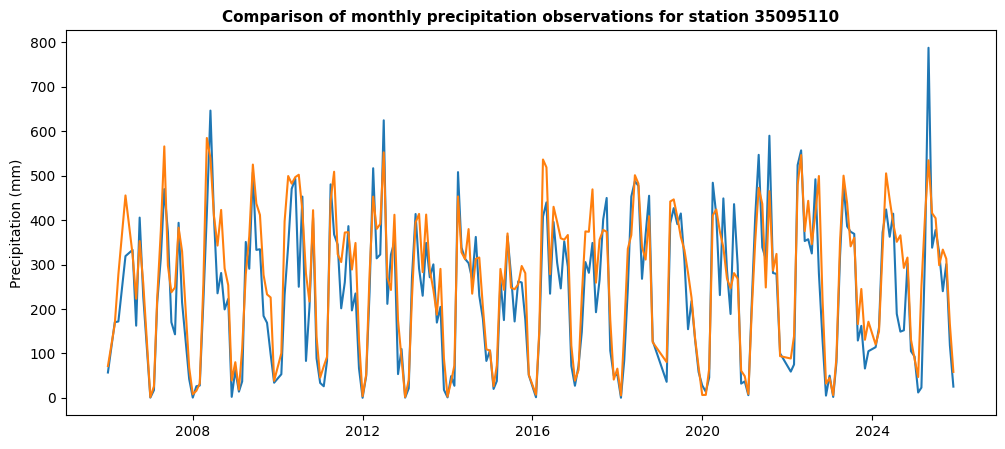

In [122]:
fig, ax = plt.subplots(1,1,figsize=(12,5))
id = '35095110'
df_plot = df_prcp_merge[df_prcp_merge['stationId']==id].copy()
ax.plot(df_plot['date'], df_plot['value'])
ax.plot(df_plot['date'], df_plot['prcp'])
ax.set_title(f'Comparison of monthly precipitation observations for station {id}', fontweight='bold', fontsize=11)
ax.set_ylabel(f'Precipitation (mm)')

# Scatter plot

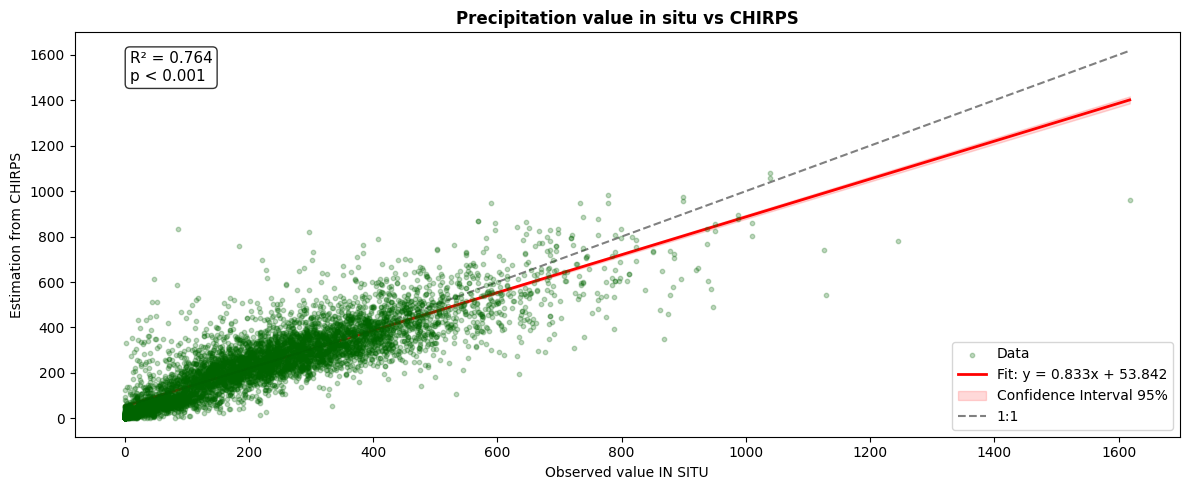

In [133]:
from scipy import stats
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
df_plot = df_prcp_merge

# Drop NaNs
x = df_plot['value'].dropna().values
y = df_plot['prcp'][df_plot['value'].dropna().index].values

# Linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Confidence band (95%)
n = len(x)
x_line = np.linspace(x.min(), x.max(), 200)
y_fit = slope * x_line + intercept

y_resid = y - (slope * x + intercept)
s_err = np.sqrt(np.sum(y_resid**2) / (n - 2))          # residual std error
x_mean = x.mean()
ss_xx = np.sum((x - x_mean)**2)
t_crit = stats.t.ppf(0.975, df=n - 2)                  # two-tailed 95%
ci = t_crit * s_err * np.sqrt(1/n + (x_line - x_mean)**2 / ss_xx)

# 1:1 line range
xy_min = min(x.min(), y.min())
xy_max = max(x.max(), y.max())

# --- Plot ---
ax.scatter(x, y, color='darkgreen', s=10, alpha=0.25, zorder=3, label='Data')

ax.plot(x_line, y_fit, color='red', linewidth=2,
        label=f'Fit: y = {slope:.3f}x + {intercept:.3f}')

ax.fill_between(x_line, y_fit - ci, y_fit + ci,
                color='red', alpha=0.15, label='Confidence Interval 95%')

ax.plot([xy_min, xy_max], [xy_min, xy_max],
        color='gray', linewidth=1.5, linestyle='--', label='1:1')

# Stats annotation
p_text = 'p < 0.001' if p_value < 0.001 else f'p = {p_value:.3f}'
ax.annotate(f'R² = {r_value**2:.3f}\n{p_text}',
            xy=(0.05, 0.88), xycoords='axes fraction',
            fontsize=11, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.legend()
ax.set_xlabel('Observed value IN SITU')
ax.set_ylabel('Estimation from CHIRPS')
ax.set_title('Precipitation value in situ vs CHIRPS', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot correlations

In [124]:
from scipy import stats

def corr_stats(g):
    valid = g[['value', 'prcp']].dropna()
    if len(valid) < 3:
        return pd.Series({'r': np.nan, 'p_value': np.nan, 'n': len(valid)})
    r, p = stats.pearsonr(valid['value'], valid['prcp'])
    return pd.Series({'r': r, 'p_value': p, 'n': len(valid)})

df_corr = (
    df_prcp_merge
    .groupby('stationId')
    .apply(corr_stats, include_groups=False)
    .reset_index()
)

In [126]:
gdf_slice = gdf_slice.merge(
    df_corr,
    how='left',
    on = ['stationId']
)
gdf_slice['r'] = gdf_slice['r']*100

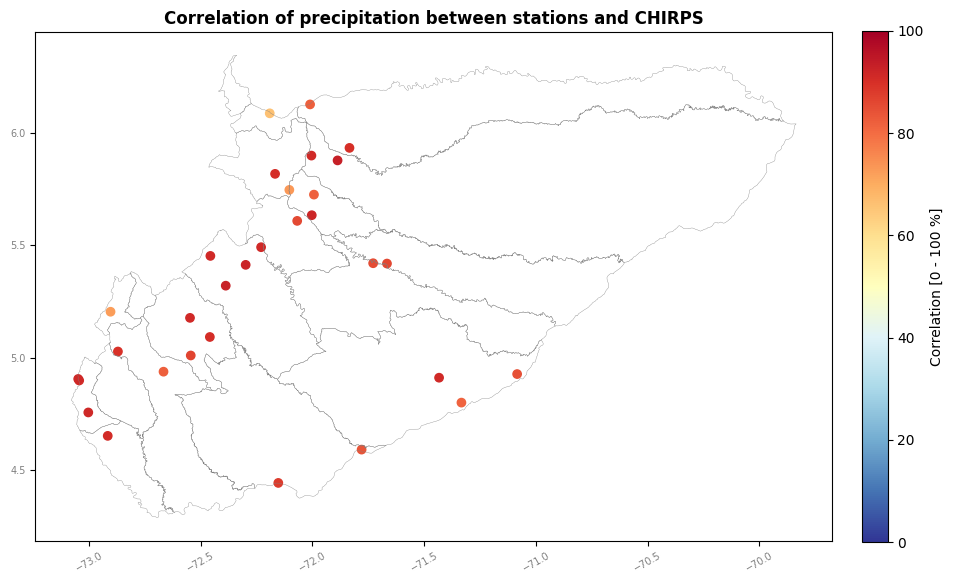

In [131]:
fig, ax = plt.subplots(1, 1, figsize=(11,9))
#ax = ax.flatten()

cmap = plt.cm.RdYlBu_r
norm = mcolors.Normalize(vmin=0, vmax=100)

gdf_co[gdf_co['DEPTO']=='CASANARE'].boundary.plot(color='gray', ax=ax, linewidth=0.25)
ax.scatter(gdf_slice['longitude'], gdf_slice['latitude'], c=gdf_slice['r'], norm=norm, cmap=cmap)
ax.set_title(f'Correlation of precipitation between stations and CHIRPS', fontsize=12, fontweight='bold')

# Change the tick parameters for better visibility
ax.tick_params(axis='x', labelcolor='gray', labelsize=7, rotation=30)
ax.tick_params(axis='y', labelcolor='gray', labelsize=7)


#cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])   # required for ScalarMappable to work in older matplotlib
cbar = fig.colorbar(sm, ax=ax, label='Correlation [0 - 100 %]', fraction=0.03, pad=0.035)

# Location of properties

In [138]:
# Read location properties
gdf_locations = gpd.read_parquet('data/client_properties.parquet')

# Work with the centroids of the properties
gdf_locations['lon'] = gdf_locations.centroid.x
gdf_locations['lat'] = gdf_locations.centroid.y

gdf_locations = gpd.GeoDataFrame(
    gdf_locations,
    geometry = gpd.points_from_xy(gdf_locations['lon'], gdf_locations['lat']),
    crs = 'EPSG:4326'
)

/tmp/ipykernel_3137578/2309375685.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_locations['lon'] = gdf_locations.centroid.x
/tmp/ipykernel_3137578/2309375685.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_locations['lat'] = gdf_locations.centroid.y


In [ ]:
import re

fig, ax = plt.subplots(1,1,figsize=(10,10))
gdf_co[gdf_co['DEPTO']=='CASANARE'].boundary.plot(color='gray', linewidth=0.5, ax=ax)
gdf_slice.plot(ax=ax, color='darkgreen', markersize=20, label='Weather Stations')
gdf_locations.plot(ax=ax, color='red', markersize=20, alpha=0.75, label='Lots')

# Label weather stations
for _, row in gdf_slice.iterrows():
    label = re.sub(r'\s*\[.*?\]', '', row['stationName']).strip()
    ax.annotate(label, xy=(row['longitude'], row['latitude']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=6, color='darkgreen')

# Label lots
for _, row in gdf_locations.iterrows():
    ax.annotate(row['Name'], xy=(row['lon'], row['lat']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=7, color='red', fontweight='bold')

ax.legend()
ax.grid(linestyle='--', color='lightgray', alpha=0.75)
ax.set_aspect('equal')
ax.set_title('Properties and Weather Station Locations', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelcolor='gray', labelsize=7, rotation=30)
ax.tick_params(axis='y', labelcolor='gray', labelsize=7)
plt.tight_layout()

In [ ]:
import re

# Filter to only stations with gauge observations
stations_with_obs = set(pd.read_parquet('data/station_observations.parquet')['stationId'])
gdf_slice_complete = gdf_slice[gdf_slice['stationId'].isin(stations_with_obs)].copy()

fig, ax = plt.subplots(1,1,figsize=(10,10))
gdf_co[gdf_co['DEPTO']=='CASANARE'].boundary.plot(color='gray', linewidth=0.5, ax=ax)
gdf_slice_complete.plot(ax=ax, color='darkgreen', markersize=20, label=f'Weather Stations (n={len(gdf_slice_complete)})')
gdf_locations.plot(ax=ax, color='red', markersize=20, alpha=0.75, label='Lots')

# Label weather stations
for _, row in gdf_slice_complete.iterrows():
    label = re.sub(r'\s*\[.*?\]', '', row['stationName']).strip()
    ax.annotate(label, xy=(row['longitude'], row['latitude']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=6, color='darkgreen')

# Label lots
for _, row in gdf_locations.iterrows():
    ax.annotate(row['Name'], xy=(row['lon'], row['lat']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=7, color='red', fontweight='bold')

ax.legend()
ax.grid(linestyle='--', color='lightgray', alpha=0.75)
ax.set_aspect('equal')
ax.set_title('Properties and Weather Stations with Observations Only', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', labelcolor='gray', labelsize=7, rotation=30)
ax.tick_params(axis='y', labelcolor='gray', labelsize=7)
plt.tight_layout()

# Northern lot activation comparison

In [ ]:
# lote 230, lote 100 has, lotes casa → MODULOS - AUT [35225030]
df_modulos = df_prcp_merge[df_prcp_merge['stationId'] == '35225030'].copy()

# Vereda Santhamarta → SANTA RITA [36010030]
df_santa_rita = df_prcp_merge[df_prcp_merge['stationId'] == '36010030'].copy()

print('MODULOS - AUT:', df_modulos.shape)
print('SANTA RITA:   ', df_santa_rita.shape)

In [ ]:
# Activation comparison

def seasonal_index(df):
    """Sum May-Sep precipitation per year for both in-situ and CHIRPS."""
    may_sep = df[df['month'].between(5, 9)]
    idx = (
        may_sep.groupby('year', as_index=False)
        .agg(
            station_index=('value', 'sum'),
            chirps_index=('prcp',  'sum')
        )
    )
    return idx

idx_modulos    = seasonal_index(df_modulos)
idx_santa_rita = seasonal_index(df_santa_rita)

print("MODULOS - AUT (May-Sep index):")
print(idx_modulos.to_string(index=False))
print("\nSANTA RITA (May-Sep index):")
print(idx_santa_rita.to_string(index=False))

In [ ]:
from scipy.stats import gamma as gamma_dist

def gamma_stats(idx, col):
    """Compute gamma distribution stats and percentiles for a seasonal index column."""
    x = idx[col].dropna()
    avg   = x.mean()
    var   = x.var(ddof=1)
    dof   = len(x) - 1
    scale = avg**2 / var
    shape = var / avg

    p1, p10, p90, p99 = gamma_dist.ppf([0.01, 0.10, 0.90, 0.99], a=scale, scale=shape)

    return pd.Series({
        'average':  round(avg, 2),
        'variance': round(var, 2),
        'dof':      dof,
        'scale':    round(scale, 4),
        'shape':    round(shape, 4),
        'p1':       round(p1,  2),
        'p10':      round(p10, 2),
        'p90':      round(p90, 2),
        'p99':      round(p99, 2),
    })

samples = [
    ('MODULOS station',    idx_modulos,    'station_index'),
    ('MODULOS CHIRPS',     idx_modulos,    'chirps_index'),
    ('SANTA RITA station', idx_santa_rita, 'station_index'),
    ('SANTA RITA CHIRPS',  idx_santa_rita, 'chirps_index'),
]

df_gamma_stats = pd.DataFrame(
    [{'sample': label, **gamma_stats(idx, col)} for label, idx, col in samples]
).set_index('sample')

df_gamma_stats

In [ ]:
def excess_payout(p):
    return np.clip((p - 90) / (99 - 90) * 100, 0, 100) * (p >= 90)

def deficit_payout(p):
    return np.clip((10 - p) / (10 - 1) * 100, 0, 100) * (p <= 10)

def activation_tables(idx, stats_row_station, stats_row_chirps):
    """Build excess and deficit policy activation tables for one subsample."""
    df = idx.copy()

    for col, stats, prefix in [
        ('chirps_index',  stats_row_chirps,  'chirps'),
        ('station_index', stats_row_station, 'station'),
    ]:
        a     = stats['scale']
        scale = stats['shape']
        pct = pd.Series(gamma_dist.cdf(df[col].values, a=a, scale=scale) * 100, index=df.index)
        df[f'{prefix}_percentile']     = pct.round(1)
        df[f'{prefix}_excess_payout']  = excess_payout(pct).round(1)
        df[f'{prefix}_deficit_payout'] = deficit_payout(pct).round(1)

    df = df.set_index('year')

    excess = df[['chirps_percentile', 'station_percentile',
                 'chirps_excess_payout', 'station_excess_payout']].copy()
    excess['discrepancy'] = (excess['chirps_excess_payout'] - excess['station_excess_payout']).round(1)

    deficit = df[['chirps_percentile', 'station_percentile',
                  'chirps_deficit_payout', 'station_deficit_payout']].copy()
    deficit['discrepancy'] = (deficit['chirps_deficit_payout'] - deficit['station_deficit_payout']).round(1)

    return excess, deficit

excess_modulos,    deficit_modulos    = activation_tables(idx_modulos,
                                                          df_gamma_stats.loc['MODULOS station'],
                                                          df_gamma_stats.loc['MODULOS CHIRPS'])
excess_santa_rita, deficit_santa_rita = activation_tables(idx_santa_rita,
                                                          df_gamma_stats.loc['SANTA RITA station'],
                                                          df_gamma_stats.loc['SANTA RITA CHIRPS'])

print("MODULOS — Excess table:")
display(excess_modulos)
print("\nMODULOS — Deficit table:")
display(deficit_modulos)
print("\nSANTA RITA — Excess table:")
display(excess_santa_rita)
print("\nSANTA RITA — Deficit table:")
display(deficit_santa_rita)